In [1]:
from obia.functions import *

In [2]:
path = "data/sample2.tif"

In [3]:
red = load_image(path)[0]
green = load_image(path)[1]
blue = load_image(path)[2]
nir = load_image(path)[3]

In [4]:
rgb = calculate_rgb(red, green, blue)

In [5]:
ndvi = calculate_ndvi(red, nir)

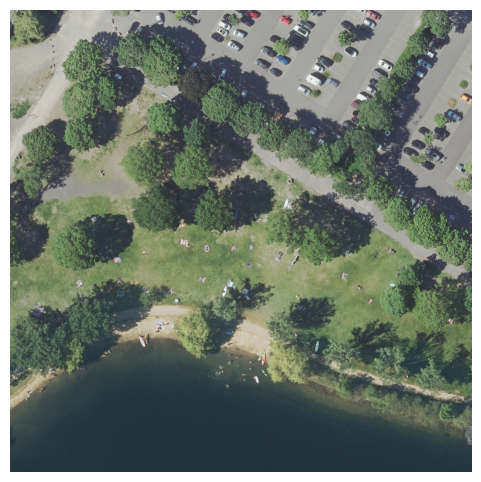

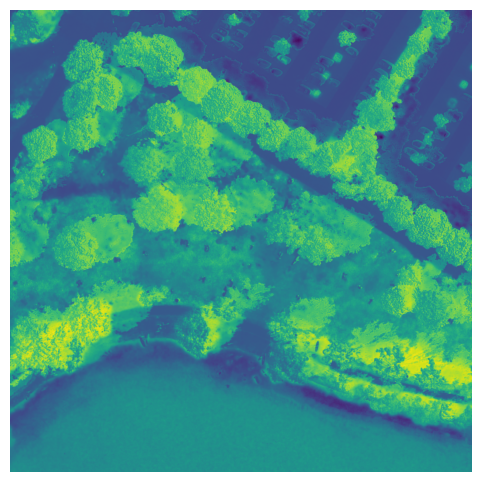

In [6]:
display_image(rgb)
display_image(ndvi)

In [7]:
seg = segmentation(rgb, 410, 8, "slic")

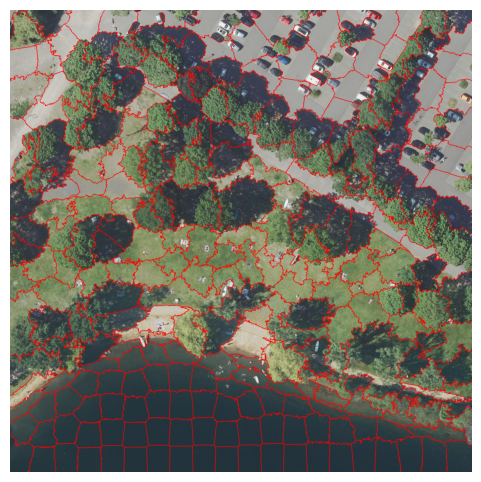

In [8]:
# display_image(seg[0])
display_image(seg[1])

In [9]:
len(np.unique(seg[0]))

262

In [21]:
features = calculate_segment_features(red, green, blue, nir, ndvi, seg[0])
features

,segment_id,red_mean,green_mean,blue_mean,nir_mean,red_std,green_std,blue_std,nir_std,intensity_mean,ndvi_mean,ndvi_std,brightness,vegetation_index
0,1,0.337104,0.358294,0.359288,0.540231,0.178820,0.172663,0.150412,0.121592,0.398729,0.267884,0.157534,1.054686,1.602566
1,2,0.753356,0.747486,0.722083,0.747811,0.069922,0.061223,0.065784,0.034006,0.742684,-0.001178,0.053196,2.222925,0.992640
2,3,0.635928,0.646091,0.613085,0.699662,0.130544,0.113465,0.132071,0.081513,0.648692,0.055734,0.128789,1.895105,1.100222
3,4,0.546154,0.562048,0.546470,0.575250,0.165245,0.164138,0.149899,0.159652,0.557481,0.030758,0.096228,1.654672,1.053273
4,5,0.547233,0.542843,0.540568,0.564889,0.176093,0.180100,0.161037,0.162415,0.548883,0.021517,0.097981,1.630643,1.032264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,258,0.134733,0.199934,0.235628,0.212615,0.007597,0.009620,0.009829,0.006248,0.195727,0.224693,0.018689,0.570295,1.578046
258,259,0.148377,0.217309,0.242705,0.217139,0.007614,0.011312,0.012346,0.006868,0.206383,0.188453,0.016076,0.608392,1.463424
259,260,0.135057,0.200075,0.235875,0.213376,0.007611,0.009452,0.009650,0.005973,0.196096,0.225269,0.018486,0.571007,1.579892
260,261,0.135116,0.200174,0.235583,0.210633,0.007430,0.009280,0.009183,0.005818,0.195376,0.218881,0.018204,0.570873,1.558898


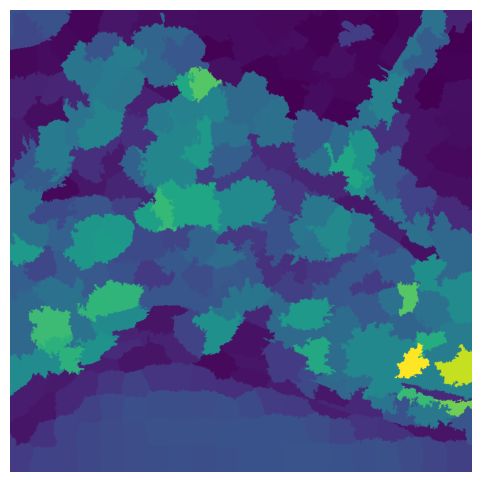

In [20]:
feature_map = dict(zip(features["segment_id"], features["vegetation_index"]))
feature_image = np.zeros_like(seg[0], dtype=float)
for seg_id, value in feature_map.items():
    feature_image[seg[0] == seg_id] = value

display_image(feature_image)
